# Projet final Fairness in AI - Classification d'images Chest X-Ray

Ce notebook est le rendu unique du projet final. Il suit l'esprit des TD1 a TD5, en l'adaptant au cadre impose du projet:
- le classifieur image est fixe et fourni par le cours,
- les images sont les seules entrees du modele,
- les metadonnees servent a mesurer et attenuer les biais,
- `train_classifieur.py` ne doit jamais etre modifie.

Le but n'est donc pas seulement d'obtenir une bonne accuracy, mais de documenter les desequilibres, montrer comment le modele amplifie ou non certains biais, puis comparer plusieurs strategies de mitigation en pre-processing et en post-processing.


## Fil conducteur et lien avec les TD

- **TD1 / TD2**: analyse descriptive, analyse bivariee, fairness metrics sur les labels et sur les predictions.
- **TD3**: audit du modele via analyse d'erreurs, sous-groupes, et inspection d'images mal classees.
- **TD4**: mitigation par pre-processing et post-processing, puis comparaison des metriques.
- **TD5**: logique de selection sur le split de validation et comparaison des combinaisons de methodes.

Contrainte importante: les methodes d'in-processing de TD5 ne sont pas compatibles avec le projet sans modifier le classifieur impose. On conserve donc l'esprit du TD5 en choisissant les meilleurs compromis sur validation et en comparant les combinaisons `pre + post`.


In [1]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display
from PIL import Image
from scipy.stats import chi2_contingency
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

from aif360.sklearn.metrics import (
    average_odds_difference,
    base_rate,
    conditional_demographic_disparity,
    df_bias_amplification,
    disparate_impact_ratio,
    equal_opportunity_difference,
    smoothed_edf,
    statistical_parity_difference,
)

try:
    from aif360.datasets import StandardDataset
    from aif360.algorithms.preprocessing import Reweighing
    AIF360_PREPROCESSING_AVAILABLE = True
except Exception as exc:
    AIF360_PREPROCESSING_AVAILABLE = False
    AIF360_IMPORT_ERROR = exc

from train_classifieur import train_classifier, pred_classifier

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', append=True, category=UserWarning)


pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'
pip install 'aif360[OptimalTransport]'


In [2]:
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

NOTEBOOK_DIR = Path('.')
DATA_DIR = NOTEBOOK_DIR / 'Al_Masri_Reina'
CSV_PATH = DATA_DIR / 'metadata.csv'
EXPERIMENT_CSV = NOTEBOOK_DIR / 'metadata_experiments.csv'
LOG_ROOT = NOTEBOOK_DIR / 'expe_log'

RUN_TRAINING = True
FORCE_RETRAIN = False
MAX_EPOCHS = 10
VALID_SPLIT_NAME = 'valid'
POSITIVE_LABEL = 'malade'
PRIVILEGED_GENDER = 1
PRIVILEGED_AGE = 1
RANDOM_STATE = 42

LOG_ROOT.mkdir(exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('CSV_PATH:', CSV_PATH)
print('EXPERIMENT_CSV:', EXPERIMENT_CSV)
print('LOG_ROOT:', LOG_ROOT)
print('RUN_TRAINING:', RUN_TRAINING)
print('MAX_EPOCHS:', MAX_EPOCHS)
print('AIF360 preprocessing available:', AIF360_PREPROCESSING_AVAILABLE)
if not AIF360_PREPROCESSING_AVAILABLE:
    print('AIF360 import issue:', AIF360_IMPORT_ERROR)


DATA_DIR: Al_Masri_Reina
CSV_PATH: Al_Masri_Reina/metadata.csv
EXPERIMENT_CSV: metadata_experiments.csv
LOG_ROOT: expe_log
RUN_TRAINING: True
MAX_EPOCHS: 10
AIF360 preprocessing available: True


In [3]:
def get_metrics(
    y_true,
    y_pred=None,
    prot_attr=None,
    priv_group=1,
    pos_label=1,
    sample_weight=None,
):
    metrics = {}
    metrics['base_rate_truth'] = base_rate(
        y_true=y_true,
        pos_label=pos_label,
        sample_weight=sample_weight,
    )
    metrics['statistical_parity_difference'] = statistical_parity_difference(
        y_true=y_true,
        y_pred=y_pred,
        prot_attr=prot_attr,
        priv_group=priv_group,
        pos_label=pos_label,
        sample_weight=sample_weight,
    )
    metrics['disparate_impact_ratio'] = disparate_impact_ratio(
        y_true=y_true,
        y_pred=y_pred,
        prot_attr=prot_attr,
        priv_group=priv_group,
        pos_label=pos_label,
        sample_weight=sample_weight,
    )
    if y_pred is not None:
        metrics['base_rate_preds'] = base_rate(
            y_true=y_pred,
            pos_label=pos_label,
            sample_weight=sample_weight,
        )
        metrics['equal_opportunity_difference'] = equal_opportunity_difference(
            y_true=y_true,
            y_pred=y_pred,
            prot_attr=prot_attr,
            priv_group=priv_group,
            pos_label=pos_label,
            sample_weight=sample_weight,
        )
        metrics['average_odds_difference'] = average_odds_difference(
            y_true=y_true,
            y_pred=y_pred,
            prot_attr=prot_attr,
            priv_group=priv_group,
            pos_label=pos_label,
            sample_weight=sample_weight,
        )
        if len(set(y_pred)) > 1:
            metrics['conditional_demographic_disparity'] = conditional_demographic_disparity(
                y_true=y_true,
                y_pred=y_pred,
                prot_attr=prot_attr,
                pos_label=pos_label,
                sample_weight=sample_weight,
            )
        else:
            metrics['conditional_demographic_disparity'] = None
        metrics['smoothed_edf'] = smoothed_edf(
            y_true=y_true,
            y_pred=y_pred,
            prot_attr=prot_attr,
            pos_label=pos_label,
            sample_weight=sample_weight,
        )
        metrics['df_bias_amplification'] = df_bias_amplification(
            y_true=y_true,
            y_pred=y_pred,
            prot_attr=prot_attr,
            pos_label=pos_label,
            sample_weight=sample_weight,
        )
        metrics['balanced_accuracy_score'] = balanced_accuracy_score(
            y_true=y_true,
            y_pred=y_pred,
            sample_weight=sample_weight,
        )
    return metrics


def clean_age_series(age_series, max_valid_age=100):
    age = pd.to_numeric(age_series, errors='coerce')
    return age.where(age.between(0, max_valid_age))


def make_age_group(age_series):
    return pd.cut(
        age_series,
        bins=[0, 40, 60, 100],
        labels=['<=40', '41-60', '>60'],
        include_lowest=True,
    )


def normalize_weights(values):
    values = pd.Series(values, dtype=float)
    return values / values.mean()


def safe_mode(series):
    mode = series.mode(dropna=True)
    return mode.iloc[0] if not mode.empty else np.nan


def add_common_columns(df):
    out = df.copy()
    out['Patient Age Clean'] = clean_age_series(out['Patient Age'])
    out['age_group'] = make_age_group(out['Patient Age Clean']).astype('object').fillna('Unknown')
    out['gender_binary'] = (out['Patient Gender'] == 'M').astype(int)
    out['age_binary'] = out['Patient Age Clean'].gt(60).fillna(False).astype(int)
    if 'label' in out.columns:
        out['has_finding'] = (out['label'] == POSITIVE_LABEL).astype(int)
    elif 'labels' in out.columns:
        out['has_finding'] = (out['labels'] == POSITIVE_LABEL).astype(int)
    else:
        out['has_finding'] = (out['Finding Labels'] != 'No Finding').astype(int)
    return out


def build_patient_table(df_img):
    df_patient = (
        df_img.groupby('Patient ID')
        .agg({
            'Patient Age Clean': 'first',
            'Patient Gender': 'first',
            'View Position': safe_mode,
            'has_finding': 'max',
            'Image Index': 'count',
        })
        .rename(columns={'Image Index': 'num_visits'})
        .reset_index()
    )
    df_patient['age_group'] = make_age_group(df_patient['Patient Age Clean']).astype('object').fillna('Unknown')
    df_patient['gender_binary'] = (df_patient['Patient Gender'] == 'M').astype(int)
    df_patient['age_binary'] = df_patient['Patient Age Clean'].gt(60).fillna(False).astype(int)
    return df_patient


def analyse_univariee(variable, df):
    counts = df[variable].value_counts(dropna=False)
    freqs = df[variable].value_counts(dropna=False, normalize=True).mul(100)
    mode = df[variable].mode(dropna=True)
    mode_value = mode.iloc[0] if not mode.empty else np.nan
    summary = pd.DataFrame({'effectif': counts, 'frequence_pct': freqs.round(2)})
    return summary, mode_value


def rapport_correlation(df, qualitative, quantitative):
    tmp = df[[qualitative, quantitative]].dropna()
    if tmp.empty:
        return np.nan
    groups = tmp.groupby(qualitative)[quantitative]
    mean_total = tmp[quantitative].mean()
    n_total = len(tmp)
    var_inter = sum(len(g) * (g.mean() - mean_total) ** 2 for _, g in groups) / n_total
    var_total = tmp[quantitative].var(ddof=0)
    return 0.0 if var_total == 0 else var_inter / var_total


def analyse_bivariee_quali(df, left, right):
    contingency = pd.crosstab(df[left], df[right])
    profiles = pd.crosstab(df[left], df[right], normalize='index').mul(100)
    chi2, p_value, dof, _ = chi2_contingency(contingency)
    return contingency, profiles.round(2), chi2, p_value, dof


def infer_class_names(datadir):
    train_dir = Path(datadir) / 'train'
    return sorted([
        name for name in os.listdir(train_dir)
        if (train_dir / name).is_dir() and not name.startswith('.')
    ])


In [4]:
CLASS_NAMES = infer_class_names(DATA_DIR)
POSITIVE_INDEX = CLASS_NAMES.index(POSITIVE_LABEL)
NEGATIVE_LABEL = [label for label in CLASS_NAMES if label != POSITIVE_LABEL][0]

print('Detected classes:', CLASS_NAMES)
print('Positive label:', POSITIVE_LABEL)
print('Negative label:', NEGATIVE_LABEL)


Detected classes: ['malade', 'sain']
Positive label: malade
Negative label: sain


## 1. Chargement du jeu de donnees reel du projet final

Avant toute analyse, on verifie que l'on travaille bien sur **le CSV actuel du projet final** et non sur le sous-ensemble du mi-projet GitHub. Cette verification est importante car les distributions peuvent avoir change.


In [5]:
df_img_raw = pd.read_csv(CSV_PATH)
df_img = add_common_columns(df_img_raw)
df_patient = build_patient_table(df_img)

print('Image-level shape  :', df_img.shape)
print('Patient-level shape:', df_patient.shape)
print('CSV columns:')
display(pd.Series(df_img.columns.tolist()))
display(df_img.head(3))


Image-level shape  : (5389, 20)
Patient-level shape: (1500, 9)
CSV columns:


0                     Image Index
1                  Finding Labels
2                     Follow-up #
3                      Patient ID
4                     Patient Age
5                  Patient Gender
6                   View Position
7             OriginalImage[Width
8                         Height]
9     OriginalImagePixelSpacing[x
10                             y]
11                    Unnamed: 11
12                    train_valid
13                          label
14                        WEIGHTS
15              Patient Age Clean
16                      age_group
17                  gender_binary
18                     age_binary
19                    has_finding
dtype: str

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS,Patient Age Clean,age_group,gender_binary,age_binary,has_finding
0,00000020_000.png,Pleural_Thickening,0,20,53,M,PA,2978,2991,0.143,0.143,NaN,train,malade,1,53.0,41-60,1,0,1
1,00000020_001.png,Fibrosis|Infiltration,1,20,47,M,PA,2992,2991,0.143,0.143,NaN,train,malade,1,47.0,41-60,1,0,1
2,00000020_002.png,Fibrosis|Infiltration|Pleural_Thickening,2,20,48,M,PA,2414,2991,0.143,0.143,NaN,train,malade,1,48.0,41-60,1,0,1


In [6]:
current_facts = {
    'n_images': len(df_img),
    'n_patients': df_patient['Patient ID'].nunique(),
    'n_train': int((df_img['train_valid'] == 'train').sum()),
    'n_valid': int((df_img['train_valid'] == 'valid').sum()),
    'n_malade': int((df_img['label'] == 'malade').sum()),
    'n_sain': int((df_img['label'] == 'sain').sum()),
    'n_male': int((df_img['Patient Gender'] == 'M').sum()),
    'n_female': int((df_img['Patient Gender'] == 'F').sum()),
    'n_PA': int((df_img['View Position'] == 'PA').sum()),
    'n_AP': int((df_img['View Position'] == 'AP').sum()),
    'n_age_outliers_gt100': int((pd.to_numeric(df_img['Patient Age'], errors='coerce') > 100).sum()),
}

facts_df = pd.DataFrame.from_dict(current_facts, orient='index', columns=['value'])
display(facts_df)


,value
n_images,5389
n_patients,1500
n_train,3974
n_valid,1415
n_malade,2475
n_sain,2914
n_male,2928
n_female,2461
n_PA,3389
n_AP,2000


**Constat rapide sur le dataset actuel**

- le sous-ensemble du projet final est beaucoup plus petit que celui du mi-projet GitHub,
- le split est `train / valid`, donc le `valid` sert a la fois a comparer les strategies et a choisir les seuils,
- les ecarts de genre et de `View Position` sont reels mais moderes,
- l'age contient peu d'anomalies, donc le nettoyage doit rester leger.


## 2. Utiliser aussi les images, pas seulement le CSV

Le modele voit uniquement les radiographies. Il est donc important de montrer quelques images du dataset et de rappeler que des attributs sensibles ou proxies comme `View Position` peuvent etre lisibles dans l'image elle-meme.


In [7]:
def get_true_label_col(df):
    if 'label' in df.columns:
        return 'label'
    if 'labels' in df.columns:
        return 'labels'
    raise KeyError('Aucune colonne de label verite disponible.')


def resolve_image_path(row):
    split = row['train_valid']
    if 'label' in row.index:
        label = row['label']
    elif 'labels' in row.index:
        label = row['labels']
    else:
        raise KeyError('Label introuvable pour resoudre le chemin image.')
    return DATA_DIR / split / label / row['Image Index']


def show_image_grid(df, title, rows=2, cols=4, random_state=RANDOM_STATE):
    sample_n = min(len(df), rows * cols)
    if sample_n == 0:
        print('No image available for', title)
        return
    sample = df.sample(sample_n, random_state=random_state)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_1d(axes).reshape(rows, cols)
    for ax in axes.ravel():
        ax.axis('off')
    for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
        img_path = resolve_image_path(row)
        img = Image.open(img_path).convert('L')
        ax.imshow(img, cmap='gray')
        cell_title = f"{row['Image Index']}\n{row['train_valid']} | {row[get_true_label_col(pd.DataFrame([row]))]} | {row['Patient Gender']} | {row['View Position']}"
        ax.set_title(cell_title, fontsize=8)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


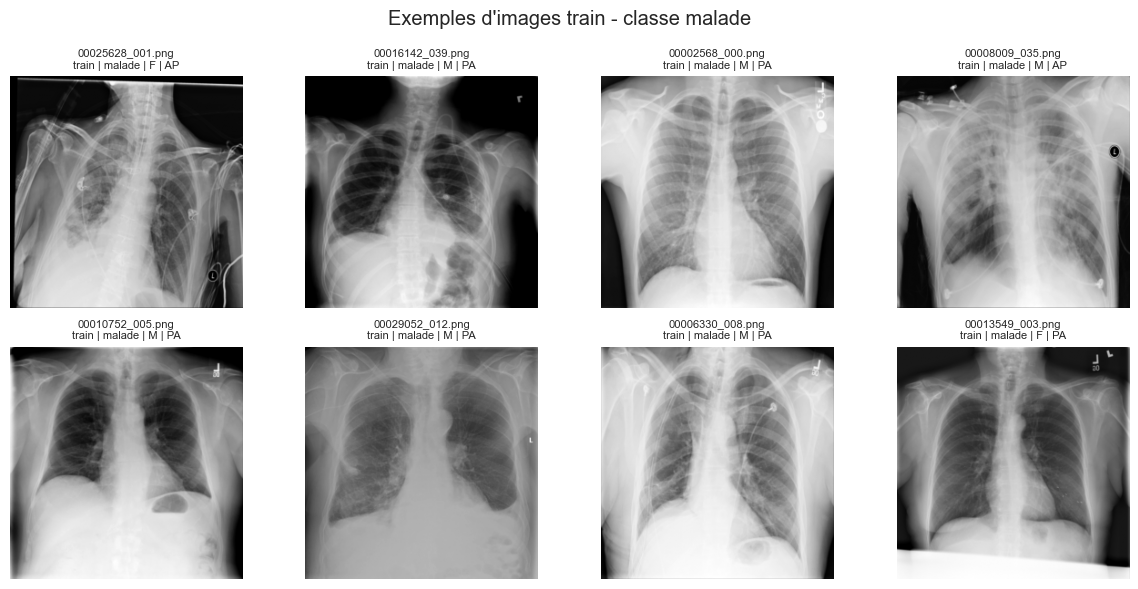

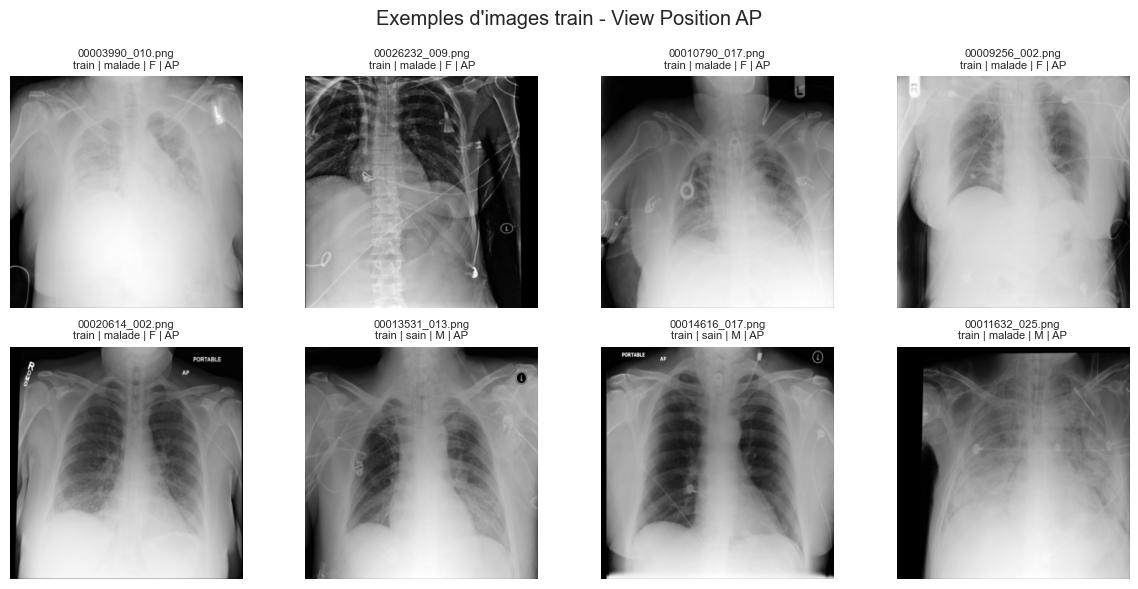

In [8]:
show_image_grid(
    df_img[(df_img['train_valid'] == 'train') & (df_img['label'] == 'malade')],
    title="Exemples d'images train - classe malade",
)

show_image_grid(
    df_img[(df_img['train_valid'] == 'train') & (df_img['View Position'] == 'AP')],
    title="Exemples d'images train - View Position AP",
)


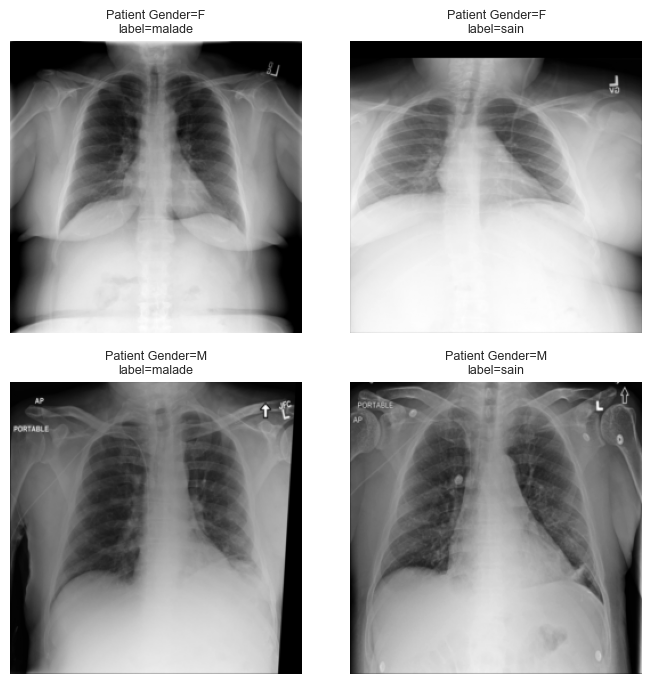

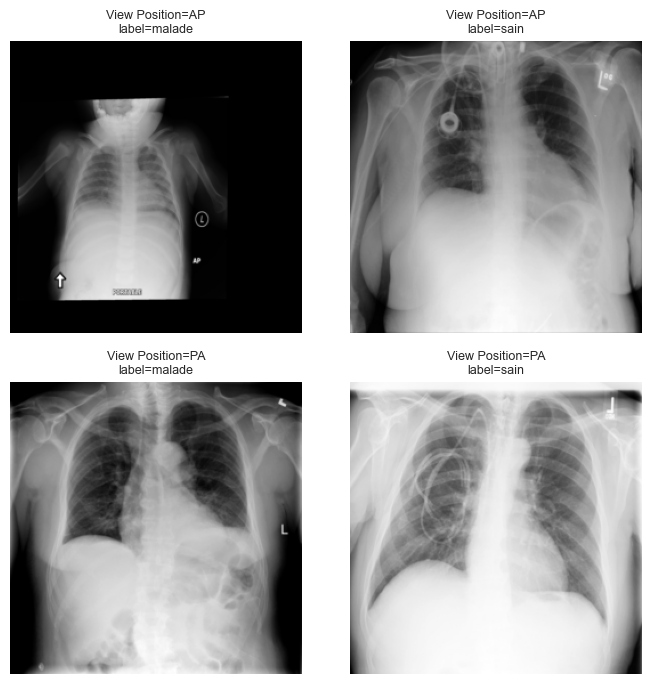

In [9]:
def stratified_image_examples(df, row_group, col_group, split='train', samples_per_cell=1, random_state=RANDOM_STATE):
    subset = df[df['train_valid'] == split].copy()
    row_values = sorted([x for x in subset[row_group].dropna().unique()])
    col_values = sorted([x for x in subset[col_group].dropna().unique()])
    nrows = len(row_values)
    ncols = len(col_values) * samples_per_cell
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.5 * nrows))
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for ax in axes.ravel():
        ax.axis('off')

    for i, row_value in enumerate(row_values):
        for j, col_value in enumerate(col_values):
            cell_df = subset[(subset[row_group] == row_value) & (subset[col_group] == col_value)]
            if cell_df.empty:
                continue
            chosen = cell_df.sample(min(samples_per_cell, len(cell_df)), random_state=random_state)
            for k, (_, row) in enumerate(chosen.iterrows()):
                ax = axes[i, j * samples_per_cell + k]
                img = Image.open(resolve_image_path(row)).convert('L')
                ax.imshow(img, cmap='gray')
                ax.set_title(f'{row_group}={row_value}\n{col_group}={col_value}', fontsize=9)
                ax.axis('off')

    plt.tight_layout()
    plt.show()

stratified_image_examples(df_img, row_group='Patient Gender', col_group='label')
stratified_image_examples(df_img, row_group='View Position', col_group='label')


## 3. TD1 / TD2 - Analyse rapide des donnees: desequilibres et biais

La consigne du projet demande une analyse plus courte que le mi-projet, mais elle doit tout de meme montrer:
- les desequilibres de distribution,
- les liens entre attributs sensibles et cible,
- des indices de biais ou de proxy susceptibles d'etre appris par le modele.


In [10]:
for variable in ['Patient Gender', 'View Position', 'age_group']:
    summary, mode_value = analyse_univariee(variable, df_patient)
    print(f'--- Analyse univariee de {variable} ---')
    display(summary)
    print('Mode:', mode_value)
    print()


--- Analyse univariee de Patient Gender ---


,effectif,frequence_pct
Patient Gender,,
M,816,54.4
F,684,45.6


Mode: M

--- Analyse univariee de View Position ---


,effectif,frequence_pct
View Position,,
PA,1215,81.0
AP,285,19.0


Mode: PA

--- Analyse univariee de age_group ---


,effectif,frequence_pct
age_group,,
41-60,669,44.60
<=40,526,35.07
>60,305,20.33


Mode: 41-60



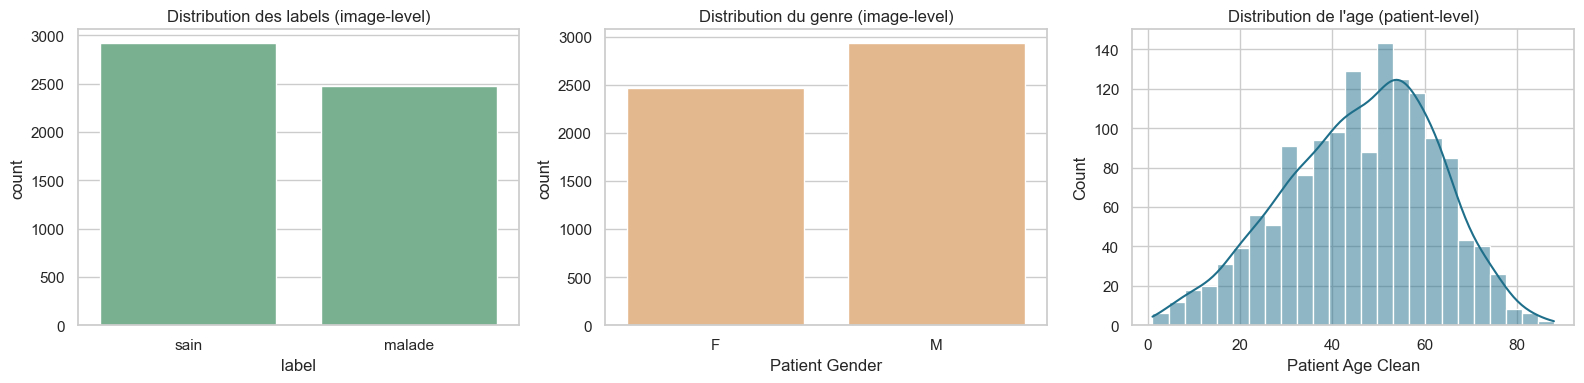

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df_img, x='label', order=['sain', 'malade'], ax=axes[0], color='#6fb98f')
axes[0].set_title('Distribution des labels (image-level)')

sns.countplot(data=df_img, x='Patient Gender', order=['F', 'M'], ax=axes[1], color='#f2b880')
axes[1].set_title('Distribution du genre (image-level)')

age_plot_df = df_patient.dropna(subset=['Patient Age Clean'])
sns.histplot(age_plot_df['Patient Age Clean'], bins=25, kde=True, ax=axes[2], color='#1f6f8b')
axes[2].set_title("Distribution de l'age (patient-level)")

plt.tight_layout()
plt.show()


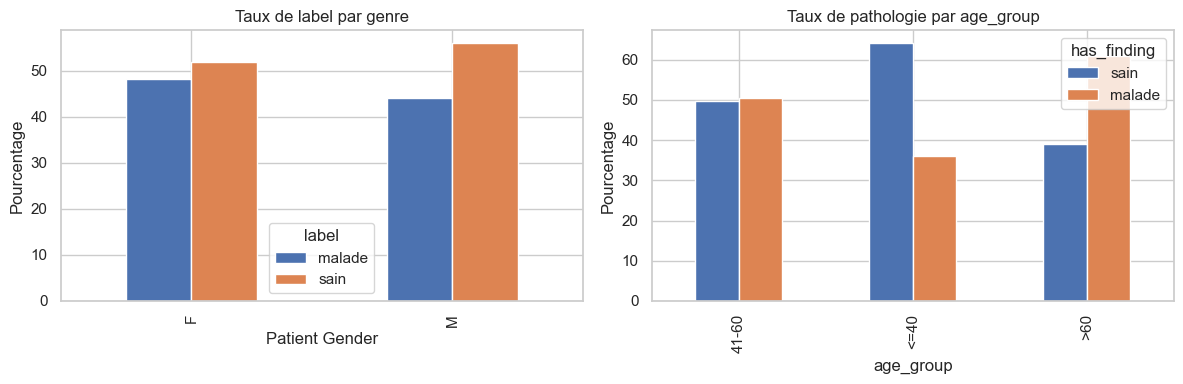

label,malade,sain
Patient Gender,,
F,48.11,51.89
M,44.09,55.91


has_finding,0,1
age_group,,
41-60,49.63,50.37
<=40,64.07,35.93
>60,39.02,60.98


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_ctab = pd.crosstab(df_img['Patient Gender'], df_img['label'], normalize='index').mul(100)
gender_ctab.plot(kind='bar', ax=axes[0], title='Taux de label par genre')
axes[0].set_ylabel('Pourcentage')
axes[0].legend(title='label')

age_ctab = pd.crosstab(df_patient['age_group'], df_patient['has_finding'], normalize='index').mul(100)
age_ctab.rename(columns={0: 'sain', 1: 'malade'}).plot(kind='bar', ax=axes[1], title='Taux de pathologie par age_group')
axes[1].set_ylabel('Pourcentage')
axes[1].legend(title='has_finding')

plt.tight_layout()
plt.show()

display(gender_ctab.round(2))
display(age_ctab.round(2))


In [13]:
eta_gender_age = rapport_correlation(df_patient, 'Patient Gender', 'Patient Age Clean')
eta_gender_visits = rapport_correlation(df_patient, 'Patient Gender', 'num_visits')

comparisons = [
    ('Patient Gender', 'has_finding'),
    ('Patient Gender', 'View Position'),
    ('Patient Gender', 'age_group'),
    ('View Position', 'has_finding'),
    ('age_group', 'has_finding'),
]

print(f'eta²(Genre, Age) = {eta_gender_age:.4f}')
print(f'eta²(Genre, num_visits) = {eta_gender_visits:.4f}')
print()

for left, right in comparisons:
    contingency, profiles, chi2, p_value, dof = analyse_bivariee_quali(df_patient, left, right)
    print(f'--- {left} x {right} ---')
    display(contingency)
    display(profiles)
    print(f'Chi2={chi2:.4f}, p-value={p_value:.6g}, ddl={dof}')
    print()


eta²(Genre, Age) = 0.0010
eta²(Genre, num_visits) = 0.0000

--- Patient Gender x has_finding ---


has_finding,0,1
Patient Gender,,
F,363,321
M,425,391


has_finding,0,1
Patient Gender,,
F,53.07,46.93
M,52.08,47.92


Chi2=0.1084, p-value=0.741928, ddl=1

--- Patient Gender x View Position ---


View Position,AP,PA
Patient Gender,,
F,121,563
M,164,652


...

has_finding,0,1
View Position,,
AP,32.98,67.02
PA,57.12,42.88


Chi2=52.9711, p-value=3.38487e-13, ddl=1

--- age_group x has_finding ---


has_finding,0,1
age_group,,
41-60,332,337
<=40,337,189
>60,119,186


has_finding,0,1
age_group,,
41-60,49.63,50.37
<=40,64.07,35.93
>60,39.02,60.98


Chi2=52.6826, p-value=3.63184e-12, ddl=2



In [14]:
all_labels = df_img['Finding Labels'].str.split('|').explode()
top_diseases = all_labels[all_labels != 'No Finding'].value_counts().head(8).index.tolist()

prevalence_rows = []
for disease in top_diseases:
    patient_flag = (
        df_img.assign(flag=df_img['Finding Labels'].str.contains(disease, regex=False))
        .groupby('Patient ID')
        .agg({'flag': 'max', 'Patient Gender': 'first'})
        .reset_index()
    )
    for gender in ['F', 'M']:
        rate = patient_flag.loc[patient_flag['Patient Gender'] == gender, 'flag'].mean() * 100
        prevalence_rows.append({'Pathologie': disease, 'Genre': gender, 'Prevalence (%)': rate})

df_prev = pd.DataFrame(prevalence_rows)
fig = px.bar(
    df_prev,
    x='Pathologie',
    y='Prevalence (%)',
    color='Genre',
    barmode='group',
    title='Prevalence des pathologies les plus frequentes par genre',
)
fig.update_layout(xaxis_tickangle=-40)
fig.show()


## 4. Fairness des labels et analyse proxy avant tout modele

Cette etape suit directement les TD: avant de juger le modele, on mesure deja les biais presents dans les labels et dans les variables corrigees ou proxy.


In [15]:
label_gender_metrics = get_metrics(
    y_true=df_patient['has_finding'].to_numpy(),
    y_pred=df_patient['has_finding'].to_numpy(),
    prot_attr=df_patient['gender_binary'].to_numpy(),
    priv_group=PRIVILEGED_GENDER,
    pos_label=1,
)

label_age_metrics = get_metrics(
    y_true=df_patient['has_finding'].to_numpy(),
    y_pred=df_patient['has_finding'].to_numpy(),
    prot_attr=df_patient['age_binary'].to_numpy(),
    priv_group=PRIVILEGED_AGE,
    pos_label=1,
)

label_fairness_df = pd.DataFrame({
    'gender': label_gender_metrics,
    'age_gt_60': label_age_metrics,
}).round(4)

display(label_fairness_df)


,gender,age_gt_60
base_rate_truth,0.4747,0.4747
statistical_parity_difference,-0.0099,-0.1697
disparate_impact_ratio,0.9794,0.7218
base_rate_preds,0.4747,0.4747
equal_opportunity_difference,0.0000,0.0000
average_odds_difference,0.0000,0.0000
conditional_demographic_disparity,-0.0009,0.0654
smoothed_edf,0.0208,0.3601
df_bias_amplification,0.0000,0.0000
balanced_accuracy_score,1.0000,1.0000


In [16]:
proxy_summary = pd.DataFrame([
    {'link': 'Genre x Age', 'measure': 'eta²', 'value': rapport_correlation(df_patient, 'Patient Gender', 'Patient Age Clean')},
    {'link': 'Genre x num_visits', 'measure': 'eta²', 'value': rapport_correlation(df_patient, 'Patient Gender', 'num_visits')},
    {'link': 'Genre x View Position', 'measure': 'chi2 p-value', 'value': analyse_bivariee_quali(df_patient, 'Patient Gender', 'View Position')[3]},
    {'link': 'Genre x age_group', 'measure': 'chi2 p-value', 'value': analyse_bivariee_quali(df_patient, 'Patient Gender', 'age_group')[3]},
    {'link': 'View Position x target', 'measure': 'chi2 p-value', 'value': analyse_bivariee_quali(df_patient, 'View Position', 'has_finding')[3]},
])

display(proxy_summary)


,link,measure,value
0,Genre x Age,eta²,9.505423e-04
1,Genre x num_visits,eta²,4.586623e-07
2,Genre x View Position,chi2 p-value,2.635871e-01
3,Genre x age_group,chi2 p-value,6.013357e-02
4,View Position x target,chi2 p-value,3.384872e-13


## 5. TD4 - Pre-processing compatible avec le classifieur image impose

Le point cle ici est de rester coherent avec le pipeline impose.

Certaines methodes de TD4 comme `DisparateImpactRemover` modifient les features tabulaires. Cela n'aurait pas d'effet direct ici, puisque le modele ne consomme que l'image. En revanche, les **poids d'instances** sont pleinement compatibles avec le script fourni. On se concentre donc sur plusieurs strategies de pondération.


In [17]:
def inverse_frequency_weights(df, group_cols):
    counts = df.groupby(group_cols)['Image Index'].transform('count')
    return normalize_weights(1.0 / counts)


def build_reweighing_weights(df, protected_col, privileged_value=1):
    if not AIF360_PREPROCESSING_AVAILABLE:
        return normalize_weights(np.ones(len(df)))

    rw_df = df[[protected_col, 'has_finding']].copy()
    rw_df['dummy_feature'] = 0

    dataset = StandardDataset(
        df=rw_df,
        label_name='has_finding',
        favorable_classes=[1],
        protected_attribute_names=[protected_col],
        privileged_classes=[[privileged_value]],
        categorical_features=[],
        features_to_keep=['dummy_feature', protected_col, 'has_finding'],
    )

    rw = Reweighing(
        unprivileged_groups=[{protected_col: 0}],
        privileged_groups=[{protected_col: privileged_value}],
    )
    dataset_rw = rw.fit_transform(dataset)
    return normalize_weights(dataset_rw.instance_weights)


df_model = df_img.copy()
df_model['WEIGHTS_BASELINE'] = 1.0
df_model['WEIGHTS_COURSE'] = normalize_weights(pd.to_numeric(df_model['WEIGHTS'], errors='coerce').fillna(1.0))
df_model['WEIGHTS_CLASS_BALANCED'] = inverse_frequency_weights(df_model, ['label'])
df_model['WEIGHTS_GENDER_RW'] = build_reweighing_weights(df_model, 'gender_binary', privileged_value=PRIVILEGED_GENDER)
df_model['WEIGHTS_AGE_RW'] = build_reweighing_weights(df_model, 'age_binary', privileged_value=PRIVILEGED_AGE)
df_model['WEIGHTS_GENDER_LABEL'] = inverse_frequency_weights(df_model, ['Patient Gender', 'label'])
df_model['WEIGHTS_VIEW_LABEL'] = inverse_frequency_weights(df_model, ['View Position', 'label'])

df_model.to_csv(EXPERIMENT_CSV, index=False)

weight_columns = [
    'WEIGHTS_BASELINE',
    'WEIGHTS_COURSE',
    'WEIGHTS_CLASS_BALANCED',
    'WEIGHTS_GENDER_RW',
    'WEIGHTS_AGE_RW',
    'WEIGHTS_GENDER_LABEL',
    'WEIGHTS_VIEW_LABEL',
]

print('Experiment CSV written to:', EXPERIMENT_CSV)
display(df_model[['Image Index', 'label', 'Patient Gender', 'View Position', 'age_group'] + weight_columns].head())


Experiment CSV written to: metadata_experiments.csv


,Image Index,label,Patient Gender,View Position,age_group,WEIGHTS_BASELINE,WEIGHTS_COURSE,WEIGHTS_CLASS_BALANCED,WEIGHTS_GENDER_RW,WEIGHTS_AGE_RW,WEIGHTS_GENDER_LABEL,WEIGHTS_VIEW_LABEL
0,00000020_000.png,malade,M,PA,41-60,1.0,1.0,1.088687,1.041626,1.050151,1.043571,0.905410
1,00000020_001.png,malade,M,PA,41-60,1.0,1.0,1.088687,1.041626,1.050151,1.043571,0.905410
2,00000020_002.png,malade,M,PA,41-60,1.0,1.0,1.088687,1.041626,1.050151,1.043571,0.905410
3,00000026_000.png,malade,M,PA,>60,1.0,1.0,1.088687,1.041626,0.857111,1.043571,0.905410
4,00000082_000.png,sain,M,PA,41-60,1.0,1.0,0.924674,0.967172,0.961019,0.822999,0.708706


In [18]:
weight_diagnostics = []
for col in weight_columns:
    stats = df_model[col].describe()[['mean', 'std', 'min', 'max']].to_dict()
    stats['weight_col'] = col
    weight_diagnostics.append(stats)

weight_diagnostics_df = pd.DataFrame(weight_diagnostics).set_index('weight_col').round(4)
display(weight_diagnostics_df)


,mean,std,min,max
weight_col,,,,
WEIGHTS_BASELINE,1.0,0.0000,1.0000,1.0000
WEIGHTS_COURSE,1.0,0.0000,1.0000,1.0000
WEIGHTS_CLASS_BALANCED,1.0,0.0817,0.9247,1.0887
WEIGHTS_GENDER_RW,1.0,0.0402,0.9546,1.0421
WEIGHTS_AGE_RW,1.0,0.0823,0.8571,1.1650
WEIGHTS_GENDER_LABEL,1.0,0.1219,0.8230,1.1379
WEIGHTS_VIEW_LABEL,1.0,0.2780,0.7087,1.3650


## 6. Entrainement du modele image et prediction

`train_classifieur.py` reste inchangé. Tout ce que fait le notebook est:
- ecrire un CSV enrichi avec de nouvelles colonnes de poids,
- lancer `train_classifier(...)`,
- lancer `pred_classifier(...)`,
- comparer les sorties sur le split `valid`.

Pour eviter de relancer les entrainements par erreur, `RUN_TRAINING = False` par defaut.


In [19]:
EXPERIMENTS = [
    {'run': 'baseline_unweighted', 'weights_col': 'WEIGHTS_BASELINE', 'active': True},
    {'run': 'course_weights', 'weights_col': 'WEIGHTS_COURSE', 'active': True},
    {'run': 'class_balanced', 'weights_col': 'WEIGHTS_CLASS_BALANCED', 'active': True},
    {'run': 'gender_rw', 'weights_col': 'WEIGHTS_GENDER_RW', 'active': True},
    {'run': 'age_rw', 'weights_col': 'WEIGHTS_AGE_RW', 'active': True},
    {'run': 'gender_label_balanced', 'weights_col': 'WEIGHTS_GENDER_LABEL', 'active': True},
    {'run': 'view_label_balanced', 'weights_col': 'WEIGHTS_VIEW_LABEL', 'active': False},
]

display(pd.DataFrame(EXPERIMENTS))


,run,weights_col,active
0,baseline_unweighted,WEIGHTS_BASELINE,True
1,course_weights,WEIGHTS_COURSE,True
2,class_balanced,WEIGHTS_CLASS_BALANCED,True
3,gender_rw,WEIGHTS_GENDER_RW,True
4,age_rw,WEIGHTS_AGE_RW,True
5,gender_label_balanced,WEIGHTS_GENDER_LABEL,True
6,view_label_balanced,WEIGHTS_VIEW_LABEL,False


In [20]:
pip install -U tensorboard


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
def find_checkpoint(logdir):
    matches = sorted(glob.glob(str(Path(logdir) / '*.ckpt')))
    return matches[0] if matches else None


def run_single_experiment(run_name, weights_col, csv_path=EXPERIMENT_CSV):
    logdir = LOG_ROOT / run_name
    preds_path = logdir / 'preds.csv'
    ckpt_path = find_checkpoint(logdir)

    should_train = RUN_TRAINING and (FORCE_RETRAIN or ckpt_path is None)
    should_predict = RUN_TRAINING and (FORCE_RETRAIN or not preds_path.exists())

    if should_train:
        ckpt_path, ckpt_score = train_classifier(
            logdir=str(logdir),
            datadir=str(DATA_DIR),
            csv=str(csv_path),
            weights_col=weights_col,
            max_epochs=MAX_EPOCHS,
        )
        print(run_name, 'trained with best score =', ckpt_score)

    if should_predict:
        ckpt_path = ckpt_path or find_checkpoint(logdir)
        if ckpt_path is None:
            raise FileNotFoundError(f'Aucun checkpoint disponible pour {run_name}')
        pred_classifier(
            datadir=str(DATA_DIR),
            ckpt_path=str(ckpt_path),
            csv_in=str(csv_path),
            csv_out=str(preds_path),
        )

    return {
        'run': run_name,
        'weights_col': weights_col,
        'logdir': str(logdir),
        'ckpt_path': ckpt_path or find_checkpoint(logdir),
        'preds_path': str(preds_path),
        'preds_exists': preds_path.exists(),
    }


experiment_registry = []
for exp in EXPERIMENTS:
    if exp['active']:
        experiment_registry.append(run_single_experiment(exp['run'], exp['weights_col']))

experiment_registry_df = pd.DataFrame(experiment_registry)
display(experiment_registry_df)


metadata_experiments.csv expe_log/baseline_unweighted/csv_in_WEIGHTS_BASELINE.csv
num_workers set to : 8


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


num_workers set to : 8
batch_size set to : 16
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/faresshretah/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:49<00:00, 945kB/s] 
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type                  | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model | ResNet                | 11.2 M | train | 0    
1 | cm    | BinaryConfusionMatrix | 0      | train | 0    
----------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.710    Total estimated model params size (MB)
69        Modules in train mode
0         Modules in eval mode
0         Total Flops


Start training


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Exception ignored in atexit callback <bound method finalize._exitfunc of <class 'weakref.finalize'>>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x11f31d4e0>
Traceback (most recent call last):
  File "/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
:
Exception ignored in atexit callback <bound method finalize._exitfunc of <class 'weakref.finalize'>>:
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/weakref.py", line 666, in _exitfunc
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/weakref.py", line 666, in _exitfunc
Exception ignored in atexit callback <bound method finalize._exitfunc of <class 'weakref.finalize'>>:
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/p

RuntimeError: Connection refused

## 7. TD1 / TD3 - Audit du modele sur les predictions

Cette section est la partie "modele" du projet:
- performance globale,
- fairness des predictions,
- analyse par sous-groupes,
- erreurs et faux positifs/faux negatifs,
- inspection d'images mal classees.


In [23]:
def softmax_np(logits):
    logits = np.asarray(logits, dtype=float)
    logits = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)


def prepare_prediction_frame(df_pred):
    df_eval = add_common_columns(df_pred)
    logit_cols = sorted(
        [col for col in df_eval.columns if col.startswith('preds_logit')],
        key=lambda col: int(col.replace('preds_logit', '')),
    )
    probs = softmax_np(df_eval[logit_cols].to_numpy())
    df_eval['score_malade'] = probs[:, POSITIVE_INDEX]
    df_eval['y_true'] = (df_eval['labels'] == POSITIVE_LABEL).astype(int)
    df_eval['y_pred'] = (df_eval['preds'] == POSITIVE_LABEL).astype(int)
    df_eval['error'] = (df_eval['y_true'] != df_eval['y_pred']).astype(int)
    return df_eval


def fairness_summary(y_true, y_pred, prot_attr, priv_group):
    metrics = get_metrics(
        y_true=np.asarray(y_true),
        y_pred=np.asarray(y_pred),
        prot_attr=np.asarray(prot_attr),
        priv_group=priv_group,
        pos_label=1,
    )
    return {
        'SPD': metrics['statistical_parity_difference'],
        'DIR': metrics['disparate_impact_ratio'],
        'EOD': metrics['equal_opportunity_difference'],
        'AOD': metrics['average_odds_difference'],
    }


def evaluate_run(df_pred, run_name, stage='raw', split_name=VALID_SPLIT_NAME, y_pred_override=None):
    df_eval = prepare_prediction_frame(df_pred)
    df_eval = df_eval[df_eval['train_valid'] == split_name].copy()
    y_true = df_eval['y_true'].to_numpy()
    y_pred = df_eval['y_pred'].to_numpy() if y_pred_override is None else np.asarray(y_pred_override)

    gender_metrics = fairness_summary(y_true, y_pred, df_eval['gender_binary'], PRIVILEGED_GENDER)
    age_metrics = fairness_summary(y_true, y_pred, df_eval['age_binary'], PRIVILEGED_AGE)

    return {
        'run': run_name,
        'stage': stage,
        'split': split_name,
        'n': len(df_eval),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
        'gender_SPD': gender_metrics['SPD'],
        'gender_DIR': gender_metrics['DIR'],
        'gender_EOD': gender_metrics['EOD'],
        'gender_AOD': gender_metrics['AOD'],
        'age_SPD': age_metrics['SPD'],
        'age_DIR': age_metrics['DIR'],
        'age_EOD': age_metrics['EOD'],
        'age_AOD': age_metrics['AOD'],
    }


def subgroup_report(df_eval, group_col):
    rows = []
    for group_value, group_df in df_eval.groupby(group_col):
        y_true = group_df['y_true'].to_numpy()
        y_pred = group_df['y_pred'].to_numpy()
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        tnr = tn / (tn + fp) if (tn + fp) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        fnr = fn / (fn + tp) if (fn + tp) else np.nan
        rows.append({
            group_col: group_value,
            'n': len(group_df),
            'prevalence': group_df['y_true'].mean(),
            'positive_prediction_rate': group_df['y_pred'].mean(),
            'error_rate': (group_df['y_true'] != group_df['y_pred']).mean(),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'TPR': tpr,
            'TNR': tnr,
            'FPR': fpr,
            'FNR': fnr,
        })
    return pd.DataFrame(rows).sort_values(group_col)


def plot_group_confusion_matrices(df_eval, group_col, title_prefix):
    groups = list(df_eval[group_col].dropna().unique())
    fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 4))
    axes = np.atleast_1d(axes)
    for ax, value in zip(axes, groups):
        group_df = df_eval[df_eval[group_col] == value]
        cm = confusion_matrix(group_df['y_true'], group_df['y_pred'], labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
        ax.set_title(f'{title_prefix} - {group_col}={value}')
        ax.set_xlabel('Pred')
        ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()


In [24]:
available_predictions = {}
raw_results = []

for exp in EXPERIMENTS:
    if not exp['active']:
        continue
    preds_path = LOG_ROOT / exp['run'] / 'preds.csv'
    if preds_path.exists():
        df_pred = pd.read_csv(preds_path)
        available_predictions[exp['run']] = df_pred
        raw_results.append(evaluate_run(df_pred, exp['run'], stage='raw'))

raw_results_df = pd.DataFrame(raw_results)
if raw_results_df.empty:
    print('Aucun preds.csv disponible. Mettez RUN_TRAINING=True ou reutilisez des runs deja presents.')
else:
    raw_results_df = raw_results_df.sort_values('balanced_accuracy', ascending=False).reset_index(drop=True)
    display(raw_results_df.round(4))


,run,stage,split,n,balanced_accuracy,accuracy,gender_SPD,gender_DIR,gender_EOD,gender_AOD,age_SPD,age_DIR,age_EOD,age_AOD
0,baseline_unweighted,raw,valid,1415,0.6626,0.6721,0.1693,1.6078,0.1755,0.1458,-0.0419,0.8926,0.0543,-0.041


In [25]:
if not raw_results_df.empty:
    fig = px.bar(
        raw_results_df,
        x='run',
        y='balanced_accuracy',
        color='run',
        text_auto='.4f',
        title='Performance globale des strategies de pondération sur validation',
    )
    fig.update_layout(showlegend=False)
    fig.show()

    fig = px.bar(
        raw_results_df.assign(abs_gender_SPD=raw_results_df['gender_SPD'].abs()),
        x='run',
        y='abs_gender_SPD',
        color='run',
        text_auto='.4f',
        title='|SPD genre| par strategie de pre-processing',
    )
    fig.update_layout(showlegend=False)
    fig.show()


Audit run: baseline_unweighted


,Patient Gender,n,prevalence,positive_prediction_rate,error_rate,balanced_accuracy,TPR,TNR,FPR,FNR
0,F,661,0.5068,0.4478,0.3283,0.6725,0.6179,0.727,0.273,0.3821
1,M,754,0.4257,0.2785,0.3276,0.6427,0.4424,0.843,0.157,0.5576


,age_group,n,prevalence,positive_prediction_rate,error_rate,balanced_accuracy,TPR,TNR,FPR,FNR
0,41-60,569,0.4991,0.3849,0.3251,0.6747,0.5599,0.7895,0.2105,0.4401
1,<=40,535,0.4374,0.3103,0.2879,0.6914,0.5256,0.8571,0.1429,0.4744
2,>60,310,0.4419,0.3903,0.4000,0.5885,0.4891,0.6879,0.3121,0.5109
3,Unknown,1,1.0000,0.0000,1.0000,0.0000,0.0000,NaN,NaN,1.0000


,View Position,n,prevalence,positive_prediction_rate,error_rate,balanced_accuracy,TPR,TNR,FPR,FNR
0,AP,570,0.4877,0.4491,0.3579,0.6409,0.5935,0.6884,0.3116,0.4065
1,PA,845,0.4473,0.2959,0.3077,0.6727,0.4868,0.8587,0.1413,0.5132


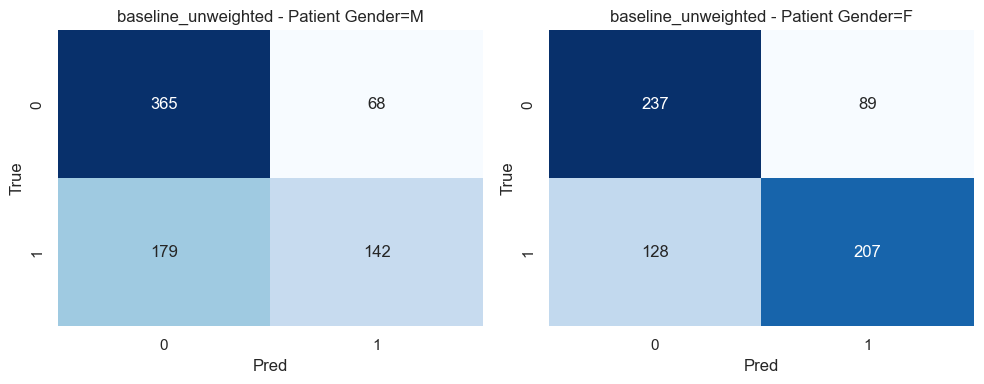

In [26]:
if not raw_results_df.empty:
    baseline_name = 'baseline_unweighted'
    best_raw_name = raw_results_df.iloc[0]['run']
    audit_name = best_raw_name if best_raw_name in available_predictions else baseline_name
    audit_df = prepare_prediction_frame(available_predictions[audit_name])
    audit_df = audit_df[audit_df['train_valid'] == VALID_SPLIT_NAME].copy()

    print('Audit run:', audit_name)
    display(subgroup_report(audit_df, 'Patient Gender').round(4))
    display(subgroup_report(audit_df, 'age_group').round(4))
    display(subgroup_report(audit_df, 'View Position').round(4))

    plot_group_confusion_matrices(audit_df, 'Patient Gender', title_prefix=audit_name)


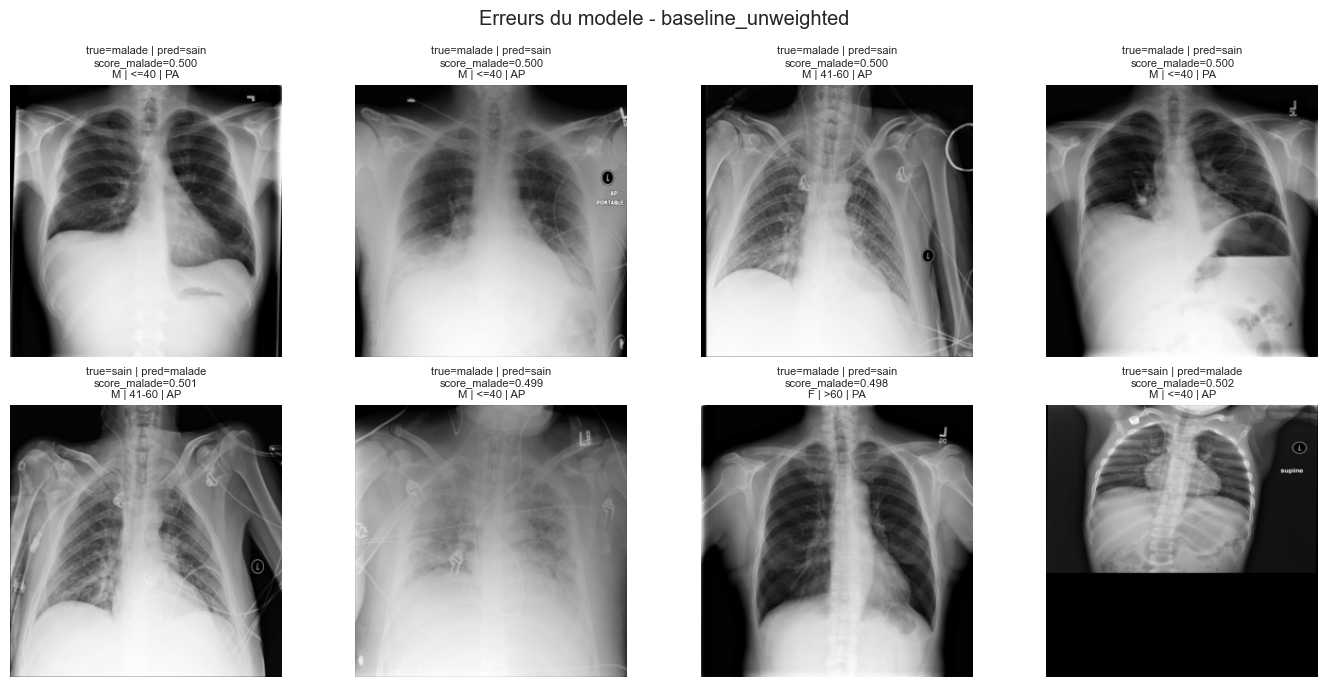

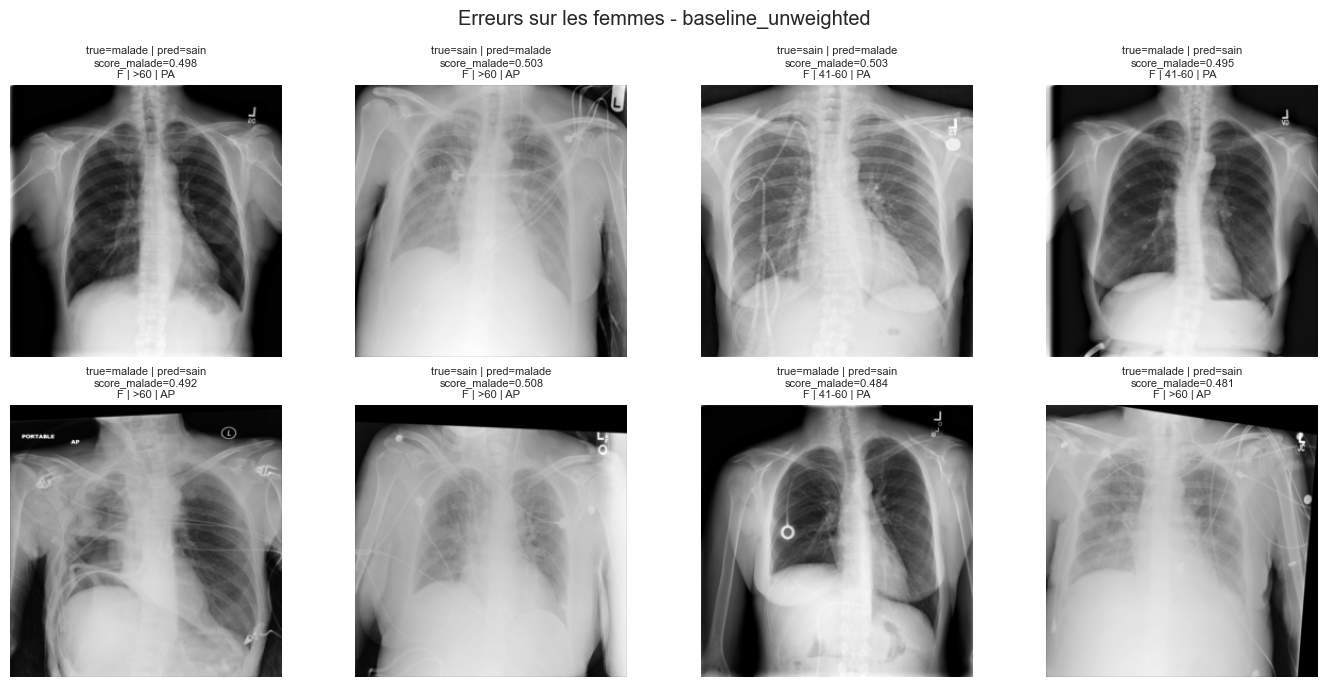

In [27]:
def show_error_gallery(df_eval, title, filter_mask=None, n=8, hardest=False):
    subset = df_eval.copy()
    if filter_mask is not None:
        subset = subset.loc[filter_mask].copy()
    subset = subset[subset['error'] == 1].copy()
    if subset.empty:
        print('No error to display for', title)
        return
    if hardest:
        subset['distance_to_boundary'] = np.abs(subset['score_malade'] - 0.5)
        subset = subset.sort_values('distance_to_boundary').head(n)
    else:
        subset = subset.head(n)

    rows = int(np.ceil(len(subset) / 4))
    fig, axes = plt.subplots(rows, 4, figsize=(14, 3.5 * rows))
    axes = np.atleast_1d(axes).reshape(rows, 4)
    for ax in axes.ravel():
        ax.axis('off')

    for ax, (_, row) in zip(axes.ravel(), subset.iterrows()):
        img = Image.open(resolve_image_path(row)).convert('L')
        ax.imshow(img, cmap='gray')
        title_text = f"true={row['labels']} | pred={row['preds']}\nscore_malade={row['score_malade']:.3f}\n{row['Patient Gender']} | {row['age_group']} | {row['View Position']}"
        ax.set_title(title_text, fontsize=8)
        ax.axis('off')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

if not raw_results_df.empty:
    show_error_gallery(audit_df, title=f'Erreurs du modele - {audit_name}', hardest=True)
    show_error_gallery(
        audit_df,
        title=f'Erreurs sur les femmes - {audit_name}',
        filter_mask=(audit_df['Patient Gender'] == 'F'),
        hardest=True,
    )


## 8. TD4 - Post-processing sur les logits exportes

Le script de prediction sauvegarde les logits par classe. Cela permet de tester plusieurs approches de post-processing sans toucher au modele:
- optimisation d'un seuil global,
- seuils differents par groupe sensible,
- version simple d'un reject option autour de la frontiere de decision.


In [28]:
def apply_global_threshold(scores, threshold):
    return (np.asarray(scores) >= threshold).astype(int)


def apply_group_thresholds(scores, groups, threshold_map):
    scores = np.asarray(scores)
    groups = np.asarray(groups)
    preds = np.zeros(len(scores), dtype=int)
    for group_value, threshold in threshold_map.items():
        mask = groups == group_value
        preds[mask] = (scores[mask] >= threshold).astype(int)
    return preds


def apply_reject_option(scores, groups, threshold=0.5, margin=0.05, privileged_value=1):
    scores = np.asarray(scores)
    groups = np.asarray(groups)
    preds = (scores >= threshold).astype(int)
    uncertain = np.abs(scores - threshold) <= margin
    preds[(groups != privileged_value) & uncertain] = 1
    preds[(groups == privileged_value) & uncertain] = 0
    return preds


def objective_score(y_true, y_pred, groups, privileged_value=1, fairness_weight=0.25, tolerance_floor=None):
    fairness = fairness_summary(y_true, y_pred, groups, privileged_value)
    bacc = balanced_accuracy_score(y_true, y_pred)
    penalty = 0.0
    if tolerance_floor is not None and bacc < tolerance_floor:
        penalty = 10 * (tolerance_floor - bacc)
    return bacc, fairness, (-bacc + fairness_weight * abs(fairness['SPD']) + 0.5 * fairness_weight * abs(fairness['EOD']) + penalty)


def search_global_threshold(df_eval, group_col='gender_binary', grid=None):
    grid = np.linspace(0.05, 0.95, 37) if grid is None else np.asarray(grid)
    y_true = df_eval['y_true'].to_numpy()
    scores = df_eval['score_malade'].to_numpy()
    groups = df_eval[group_col].to_numpy()
    rows = []
    for threshold in grid:
        y_pred = apply_global_threshold(scores, threshold)
        bacc, fairness, obj = objective_score(y_true, y_pred, groups)
        rows.append({
            'threshold': threshold,
            'balanced_accuracy': bacc,
            'accuracy': accuracy_score(y_true, y_pred),
            'SPD': fairness['SPD'],
            'DIR': fairness['DIR'],
            'EOD': fairness['EOD'],
            'objective': obj,
        })
    return pd.DataFrame(rows).sort_values(['objective', 'balanced_accuracy'], ascending=[True, False])


def search_group_thresholds(df_eval, group_col='gender_binary', grid=None, tolerance=0.03):
    grid = np.linspace(0.10, 0.90, 17) if grid is None else np.asarray(grid)
    y_true = df_eval['y_true'].to_numpy()
    scores = df_eval['score_malade'].to_numpy()
    groups = df_eval[group_col].to_numpy()
    base_bacc = balanced_accuracy_score(y_true, df_eval['y_pred'].to_numpy())
    rows = []
    for th0 in grid:
        for th1 in grid:
            y_pred = apply_group_thresholds(scores, groups, {0: th0, 1: th1})
            bacc, fairness, obj = objective_score(y_true, y_pred, groups, tolerance_floor=base_bacc - tolerance)
            rows.append({
                'threshold_group0': th0,
                'threshold_group1': th1,
                'balanced_accuracy': bacc,
                'accuracy': accuracy_score(y_true, y_pred),
                'SPD': fairness['SPD'],
                'DIR': fairness['DIR'],
                'EOD': fairness['EOD'],
                'objective': obj,
            })
    return pd.DataFrame(rows).sort_values(['objective', 'balanced_accuracy'], ascending=[True, False])


def search_reject_option(df_eval, group_col='gender_binary', threshold_grid=None, margin_grid=None, tolerance=0.03):
    threshold_grid = np.linspace(0.30, 0.70, 17) if threshold_grid is None else np.asarray(threshold_grid)
    margin_grid = np.linspace(0.01, 0.20, 20) if margin_grid is None else np.asarray(margin_grid)
    y_true = df_eval['y_true'].to_numpy()
    scores = df_eval['score_malade'].to_numpy()
    groups = df_eval[group_col].to_numpy()
    base_bacc = balanced_accuracy_score(y_true, df_eval['y_pred'].to_numpy())
    rows = []
    for threshold in threshold_grid:
        for margin in margin_grid:
            y_pred = apply_reject_option(scores, groups, threshold=threshold, margin=margin, privileged_value=PRIVILEGED_GENDER)
            bacc, fairness, obj = objective_score(y_true, y_pred, groups, tolerance_floor=base_bacc - tolerance)
            rows.append({
                'threshold': threshold,
                'margin': margin,
                'balanced_accuracy': bacc,
                'accuracy': accuracy_score(y_true, y_pred),
                'SPD': fairness['SPD'],
                'DIR': fairness['DIR'],
                'EOD': fairness['EOD'],
                'objective': obj,
            })
    return pd.DataFrame(rows).sort_values(['objective', 'balanced_accuracy'], ascending=[True, False])


In [29]:
def select_best_pre_run(results_df, baseline_run='baseline_unweighted', tolerance=0.03):
    baseline_row = results_df[results_df['run'] == baseline_run]
    baseline_bacc = baseline_row['balanced_accuracy'].iloc[0] if not baseline_row.empty else results_df['balanced_accuracy'].max()
    candidates = results_df[results_df['run'] != baseline_run].copy()
    if candidates.empty:
        return baseline_run
    candidates['fairness_gap'] = candidates['gender_SPD'].abs() + candidates['age_SPD'].abs()
    eligible = candidates[candidates['balanced_accuracy'] >= baseline_bacc - tolerance]
    if eligible.empty:
        eligible = candidates
    return eligible.sort_values(['fairness_gap', 'balanced_accuracy'], ascending=[True, False]).iloc[0]['run']


post_rows = []
search_tables = {}

if not raw_results_df.empty:
    baseline_run = 'baseline_unweighted'
    best_pre_run = select_best_pre_run(raw_results_df, baseline_run=baseline_run)
    candidate_runs = [run for run in [baseline_run, best_pre_run] if run in available_predictions]

    for run_name in candidate_runs:
        df_eval = prepare_prediction_frame(available_predictions[run_name])
        df_eval = df_eval[df_eval['train_valid'] == VALID_SPLIT_NAME].copy()

        post_rows.append(evaluate_run(available_predictions[run_name], run_name, stage='raw'))

        global_table = search_global_threshold(df_eval)
        best_global = global_table.iloc[0]
        global_pred = apply_global_threshold(df_eval['score_malade'], best_global['threshold'])
        post_rows.append(evaluate_run(available_predictions[run_name], run_name, stage=f'global_threshold_{best_global["threshold"]:.2f}', y_pred_override=global_pred))
        search_tables[(run_name, 'global_threshold')] = global_table

        group_table = search_group_thresholds(df_eval)
        best_group = group_table.iloc[0]
        group_pred = apply_group_thresholds(df_eval['score_malade'], df_eval['gender_binary'], {0: best_group['threshold_group0'], 1: best_group['threshold_group1']})
        post_rows.append(evaluate_run(available_predictions[run_name], run_name, stage=f'gender_thresholds_F{best_group["threshold_group0"]:.2f}_M{best_group["threshold_group1"]:.2f}', y_pred_override=group_pred))
        search_tables[(run_name, 'gender_thresholds')] = group_table

        reject_table = search_reject_option(df_eval)
        best_reject = reject_table.iloc[0]
        reject_pred = apply_reject_option(df_eval['score_malade'], df_eval['gender_binary'], threshold=best_reject['threshold'], margin=best_reject['margin'], privileged_value=PRIVILEGED_GENDER)
        post_rows.append(evaluate_run(available_predictions[run_name], run_name, stage=f'reject_option_t{best_reject["threshold"]:.2f}_m{best_reject["margin"]:.2f}', y_pred_override=reject_pred))
        search_tables[(run_name, 'reject_option')] = reject_table

post_results_df = pd.DataFrame(post_rows)
if post_results_df.empty:
    print("Pas encore de resultats de post-processing: il faut d'abord disposer de preds.csv.")
else:
    display(post_results_df.round(4))


/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))
/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))
/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))
/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))


,run,stage,split,n,balanced_accuracy,accuracy,gender_SPD,gender_DIR,gender_EOD,gender_AOD,age_SPD,age_DIR,age_EOD,age_AOD
0,baseline_unweighted,raw,valid,1415,0.6626,0.6721,0.1693,1.6078,0.1755,0.1458,-0.0419,0.8926,0.0543,-0.0410
1,baseline_unweighted,global_threshold_0.35,valid,1415,0.6846,0.6834,0.1431,1.3279,0.1226,0.1144,-0.0744,0.8674,0.0006,-0.0767
2,baseline_unweighted,gender_thresholds_F0.40_M0.30,valid,1415,0.6766,0.6742,0.0189,1.0370,0.0155,-0.0083,-0.0412,0.9253,0.0195,-0.0444
3,baseline_unweighted,reject_option_t0.38_m0.01,valid,1415,0.6824,0.6834,0.1590,1.3984,0.1575,0.1319,-0.0752,0.8586,-0.0029,-0.0776
4,baseline_unweighted,raw,valid,1415,0.6626,0.6721,0.1693,1.6078,0.1755,0.1458,-0.0419,0.8926,0.0543,-0.0410
5,baseline_unweighted,global_threshold_0.35,valid,1415,0.6846,0.6834,0.1431,1.3279,0.1226,0.1144,-0.0744,0.8674,0.0006,-0.0767
6,baseline_unweighted,gender_thresholds_F0.40_M0.30,valid,1415,0.6766,0.6742,0.0189,1.0370,0.0155,-0.0083,-0.0412,0.9253,0.0195,-0.0444
7,baseline_unweighted,reject_option_t0.38_m0.01,valid,1415,0.6824,0.6834,0.1590,1.3984,0.1575,0.1319,-0.0752,0.8586,-0.0029,-0.0776


In [30]:
if not post_results_df.empty:
    final_compare = post_results_df.copy()
    final_compare['method'] = final_compare['run'] + ' | ' + final_compare['stage']
    final_compare['abs_gender_SPD'] = final_compare['gender_SPD'].abs()

    fig = px.scatter(
        final_compare,
        x='abs_gender_SPD',
        y='balanced_accuracy',
        color='run',
        text='method',
        hover_data=['gender_DIR', 'gender_EOD', 'age_SPD', 'age_DIR'],
        title='Compromis fairness / performance sur validation',
    )
    fig.update_traces(textposition='top center')
    fig.show()

    display(final_compare.sort_values(['abs_gender_SPD', 'balanced_accuracy'], ascending=[True, False]).round(4))


,run,stage,split,n,balanced_accuracy,accuracy,gender_SPD,gender_DIR,gender_EOD,gender_AOD,age_SPD,age_DIR,age_EOD,age_AOD,method,abs_gender_SPD
2,baseline_unweighted,gender_thresholds_F0.40_M0.30,valid,1415,0.6766,0.6742,0.0189,1.0370,0.0155,-0.0083,-0.0412,0.9253,0.0195,-0.0444,baseline_unweighted | gender_thresholds_F0.40_...,0.0189
6,baseline_unweighted,gender_thresholds_F0.40_M0.30,valid,1415,0.6766,0.6742,0.0189,1.0370,0.0155,-0.0083,-0.0412,0.9253,0.0195,-0.0444,baseline_unweighted | gender_thresholds_F0.40_...,0.0189
1,baseline_unweighted,global_threshold_0.35,valid,1415,0.6846,0.6834,0.1431,1.3279,0.1226,0.1144,-0.0744,0.8674,0.0006,-0.0767,baseline_unweighted | global_threshold_0.35,0.1431
5,baseline_unweighted,global_threshold_0.35,valid,1415,0.6846,0.6834,0.1431,1.3279,0.1226,0.1144,-0.0744,0.8674,0.0006,-0.0767,baseline_unweighted | global_threshold_0.35,0.1431
3,baseline_unweighted,reject_option_t0.38_m0.01,valid,1415,0.6824,0.6834,0.1590,1.3984,0.1575,0.1319,-0.0752,0.8586,-0.0029,-0.0776,baseline_unweighted | reject_option_t0.38_m0.01,0.1590
7,baseline_unweighted,reject_option_t0.38_m0.01,valid,1415,0.6824,0.6834,0.1590,1.3984,0.1575,0.1319,-0.0752,0.8586,-0.0029,-0.0776,baseline_unweighted | reject_option_t0.38_m0.01,0.1590
0,baseline_unweighted,raw,valid,1415,0.6626,0.6721,0.1693,1.6078,0.1755,0.1458,-0.0419,0.8926,0.0543,-0.0410,baseline_unweighted | raw,0.1693
4,baseline_unweighted,raw,valid,1415,0.6626,0.6721,0.1693,1.6078,0.1755,0.1458,-0.0419,0.8926,0.0543,-0.0410,baseline_unweighted | raw,0.1693


In [31]:
if search_tables:
    first_key = list(search_tables.keys())[0]
    print('Example of search table:', first_key)
    display(search_tables[first_key].head(15).round(4))


Example of search table: ('baseline_unweighted', 'global_threshold')


,threshold,balanced_accuracy,accuracy,SPD,DIR,EOD,objective
12,0.350,0.6846,0.6834,0.1431,1.3279,0.1226,-0.6335
13,0.375,0.6797,0.6806,0.1422,1.3481,0.1423,-0.6264
14,0.400,0.6785,0.6813,0.1515,1.4009,0.1557,-0.6212
16,0.450,0.6782,0.6841,0.1544,1.4621,0.1514,-0.6207
11,0.325,0.6760,0.6721,0.1595,1.3416,0.1305,-0.6198
15,0.425,0.6734,0.6777,0.1531,1.4291,0.1537,-0.6160
10,0.300,0.6648,0.6580,0.1535,1.3007,0.1140,-0.6122
17,0.475,0.6693,0.6770,0.1539,1.4981,0.1498,-0.6121
9,0.275,0.6549,0.6445,0.1557,1.2789,0.1093,-0.6023
18,0.500,0.6626,0.6721,0.1693,1.6078,0.1755,-0.5983


## 9. Conclusion

La conclusion finale du rapport doit repondre clairement a ces points:

1. **Quels biais sont visibles dans les donnees ?**
   Montrer les principaux desequilibres et expliquer quels proxies sont plausibles.
2. **Le modele image amplifie-t-il certains biais ?**
   Le montrer avec les fairness metrics sur predictions, les sous-groupes et les erreurs.
3. **Quelle ponderation est la plus utile ?**
   La justifier par des chiffres de balanced accuracy et de fairness.
4. **Quel post-processing apporte le meilleur compromis ?**
   Comparer seuil global, seuils par groupe et reject option.
5. **La combinaison pre + post fait-elle mieux que chaque methode seule ?**
   C'est le point final attendu par le projet.

Limitation importante a rappeler: il n'y a pas de split test separe dans les donnees fournies ici. Les comparaisons et le choix des seuils se font donc sur `valid`, ce qui doit etre assume explicitement dans l'interpretation finale.
